In [22]:
import pandas as pd

players = pd.read_csv("../data/raw/transfermarkt/players.csv")
valuations = pd.read_csv("../data/raw/transfermarkt/player_valuations.csv")
appearances = pd.read_csv("../data/raw/transfermarkt/appearances.csv")
matches = pd.read_csv("../data/raw/football-data/E0_2324.csv")

players.shape, valuations.shape, appearances.shape, matches.shape

((50149, 26), (656301, 6), (1894350, 13), (380, 106))

In [23]:
players.info()
players[["name", "date_of_birth", "position", "sub_position", "market_value_in_eur"]]

<class 'pandas.DataFrame'>
RangeIndex: 50149 entries, 0 to 50148
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             50149 non-null  int64  
 1   first_name                            46985 non-null  str    
 2   last_name                             50149 non-null  str    
 3   name                                  50149 non-null  str    
 4   last_season                           50149 non-null  int64  
 5   current_club_id                       50149 non-null  int64  
 6   player_code                           50149 non-null  str    
 7   country_of_birth                      44264 non-null  str    
 8   city_of_birth                         44541 non-null  str    
 9   country_of_citizenship                49880 non-null  str    
 10  date_of_birth                         50100 non-null  str    
 11  sub_position              

,name,date_of_birth,position,sub_position,market_value_in_eur
0,Miroslav Klose,1978-06-09 00:00:00,Attack,Centre-Forward,1000000.0
1,Roman Weidenfeller,1980-08-06 00:00:00,Goalkeeper,Goalkeeper,750000.0
2,Dimitar Berbatov,1981-01-30 00:00:00,Attack,Centre-Forward,1000000.0
3,Lúcio,1978-05-08 00:00:00,Defender,Centre-Back,200000.0
4,Tom Starke,1981-03-18 00:00:00,Goalkeeper,Goalkeeper,100000.0
...,...,...,...,...,...
50144,Yahya Mousa Gharawi,2006-01-01 00:00:00,Missing,NaN,NaN
50145,Szabolcs Nyitra,2008-10-12 00:00:00,Midfield,Attacking Midfield,NaN
50146,Iustin Filote,2008-10-21 00:00:00,Goalkeeper,Goalkeeper,NaN
50147,Vukasin Zdravkovic,2007-12-14 00:00:00,Goalkeeper,Goalkeeper,NaN


In [24]:
core_cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HS", "AS", "HST", "AST", "HC", "AC"]
matches_core = matches[core_cols]
matches_core.info()
matches_core.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      380 non-null    str  
 1   HomeTeam  380 non-null    str  
 2   AwayTeam  380 non-null    str  
 3   FTHG      380 non-null    int64
 4   FTAG      380 non-null    int64
 5   FTR       380 non-null    str  
 6   HS        380 non-null    int64
 7   AS        380 non-null    int64
 8   HST       380 non-null    int64
 9   AST       380 non-null    int64
 10  HC        380 non-null    int64
 11  AC        380 non-null    int64
dtypes: int64(8), str(4)
memory usage: 46.5 KB


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HC,AC
0,11/08/2023,Burnley,Man City,0,3,A,6,17,1,8,6,5
1,12/08/2023,Arsenal,Nott'm Forest,2,1,H,15,6,7,2,8,3
2,12/08/2023,Bournemouth,West Ham,1,1,D,14,16,5,3,10,4
3,12/08/2023,Brighton,Luton,4,1,H,27,9,12,3,6,7
4,12/08/2023,Everton,Fulham,0,1,A,19,9,9,2,10,4
5,12/08/2023,Sheffield United,Crystal Palace,0,1,A,8,24,1,8,5,5
6,12/08/2023,Newcastle,Aston Villa,5,1,H,17,16,13,6,6,5
7,13/08/2023,Brentford,Tottenham,2,2,D,11,18,6,6,3,6
8,13/08/2023,Chelsea,Liverpool,1,1,D,10,13,4,1,4,4
9,14/08/2023,Man United,Wolves,1,0,H,15,23,3,6,8,7


In [48]:
players_clean = players.dropna(subset = ["market_value_in_eur"]).copy()

players_clean["date_of_birth"] = pd.to_datetime(players_clean["date_of_birth"])
reference_date = pd.Timestamp("2023-08-01")  # start of the 2023-24 season
players_clean["age"] = (reference_date - players_clean["date_of_birth"]).dt.days // 365

players_clean = players_clean[[
    "player_id","name", "age", "position", "sub_position", "market_value_in_eur"
]]

players_clean.shape
players_clean.head(10)
players_clean["position"].value_counts()

position
Defender      13411
Midfield      12015
Attack        11369
Goalkeeper     4604
Missing         129
Name: count, dtype: int64

In [49]:
players_clean = players_clean[players_clean["position"] != "Missing"].copy()

players_clean.isna().sum()
players_clean.describe()

,player_id,age,market_value_in_eur
count,4.139900e+04,41368.000000,4.139900e+04
mean,4.323143e+05,26.810554,1.515288e+06
std,3.378519e+05,6.708260,5.863151e+06
min,1.000000e+01,13.000000,1.000000e+04
25%,1.489220e+05,22.000000,1.000000e+05
50%,3.548860e+05,26.000000,2.750000e+05
75%,6.520565e+05,31.000000,7.000000e+05
max,1.523289e+06,53.000000,2.000000e+08


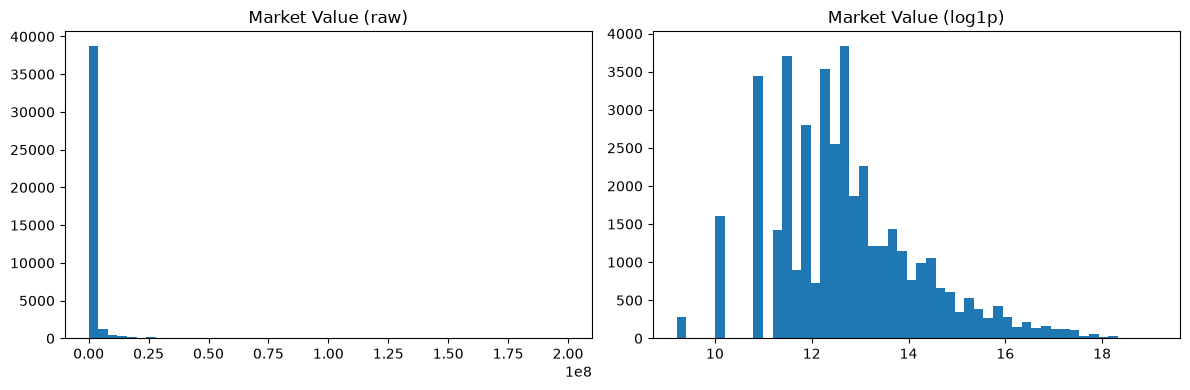

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(players_clean["market_value_in_eur"], bins=50)
axes[0].set_title("Market Value (raw)")

players_clean["log_market_value"] = np.log1p(players_clean["market_value_in_eur"])
axes[1].hist(players_clean["log_market_value"], bins=50)
axes[1].set_title("Market Value (log1p)")

plt.tight_layout()
plt.show()

In [51]:
import os

os.makedirs("data/processed", exist_ok=True)
players_clean.to_parquet("data/processed/players_value_lab.parquet", index=False)

players_clean.shape

(41399, 7)

In [52]:
players_clean = players_clean.dropna(subset=["age"]).copy()

players_clean.isna().sum()
players_clean.shape

(41368, 7)

In [53]:
from sklearn.model_selection import train_test_split

X = players_clean[["age", "position"]]
y = players_clean[["log_market_value"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape

((33094, 2), (8274, 2))

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_prediction = np.full(shape=len(y_test), fill_value=y_train.median())

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))
baseline_r2 = r2_score(y_test, baseline_prediction)

print(f"Baseline MAE (log scale): {baseline_mae:.3f}")
print(f"Baseline RMSE (log scale): {baseline_rmse:.3f}")
print(f"Baseline R^2: {baseline_r2:.3f}")

baseline_mae_eur = mean_absolute_error(np.expm1(y_test), np.expm1(baseline_prediction))

print(f"Baseline MAE (real euros): €{baseline_mae_eur:,.0f}")

Baseline MAE (log scale): 1.152
Baseline RMSE (log scale): 1.524
Baseline R^2: -0.013
Baseline MAE (real euros): €1,390,894


In [55]:
from sklearn.linear_model import LinearRegression

X_train_age = X_train[["age"]]
X_test_age = X_test[["age"]]

model_age_only = LinearRegression()
model_age_only.fit(X_train_age, y_train)

preds_age_only = model_age_only.predict(X_test_age)

mae_age_only = mean_absolute_error(y_test, preds_age_only)
r2_age_only = r2_score(y_test, preds_age_only)

mae_age_only_eur = mean_absolute_error(np.expm1(y_test), np.expm1(preds_age_only))

print(f"Age-Only MAE (log scale): {mae_age_only:.3f}")
print(f"Age-Only R^2: {r2_age_only:.3f}")
print(f"Age-Only MAE (real euros): €{mae_age_only_eur:,.0f}")

Age-Only MAE (log scale): 1.119
Age-Only R^2: 0.065
Age-Only MAE (real euros): €1,382,643


In [56]:
X_train_encoded = pd.get_dummies(X_train, columns=["position"], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=["position"], drop_first=True)

X_train_encoded.head()

,age,position_Defender,position_Goalkeeper,position_Midfield
45129,17.0,False,False,False
20036,27.0,True,False,False
30765,21.0,False,False,False
22357,22.0,True,False,False
44200,19.0,False,False,True


In [57]:
model_age_position = LinearRegression()
model_age_position.fit(X_train_encoded, y_train)

preds_age_position = model_age_position.predict(X_test_encoded)

mae_age_position = mean_absolute_error(y_test, preds_age_position)
r2_age_position = r2_score(y_test, preds_age_position)

mae_age_position_eur = mean_absolute_error(np.expm1(y_test), np.expm1(preds_age_position))

print(f"Age + Position MAE (log scale): {mae_age_position:.3f}")
print(f"Age + Position R^2: {r2_age_position:.3f}")
print(f"Age + Position MAE (real euros): €{mae_age_position_eur:,.0f}")

Age + Position MAE (log scale): 1.111
Age + Position R^2: 0.079
Age + Position MAE (real euros): €1,379,809


In [58]:
appearances.columns.tolist()

['appearance_id',
 'game_id',
 'player_id',
 'player_club_id',
 'player_current_club_id',
 'date',
 'player_name',
 'competition_id',
 'yellow_cards',
 'red_cards',
 'goals',
 'assists',
 'minutes_played']

In [59]:
appearances["date"] = pd.to_datetime(appearances["date"])

season_start = pd.Timestamp("2022-08-01")
season_end = pd.Timestamp("2023-08-01")

appearances_season = appearances[
    (appearances["date"] >= season_start) & (appearances["date"] < season_end)
]

appearances_season.shape

(141961, 13)

In [61]:
player_season_stats = appearances_season.groupby("player_id").agg(
    goals = ("goals", "sum"),
    assists = ("assists", "sum"),
    minutes_played = ("minutes_played", "sum")
).reset_index()

print(player_season_stats.shape)
player_season_stats.head()

(7499, 4)


,player_id,goals,assists,minutes_played
0,3333,0,1,1231
1,3455,1,0,144
2,4742,1,1,1756
3,5336,3,2,1315
4,7161,12,10,2738


In [63]:
players_full = players_clean.merge(player_season_stats, on="player_id", how="left")

print(players_full.shape)
players_full[["goals","assists","minutes_played"]].isna().sum()

(41368, 10)


goals             33919
assists           33919
minutes_played    33919
dtype: int64

In [64]:
players_full["goals"] = players_full["goals"].fillna(0)
players_full["assists"] = players_full["assists"].fillna(0)
players_full["minutes_played"] = players_full["minutes_played"].fillna(0)

print(players_full[["goals", "assists", "minutes_played"]].isna().sum())
players_full[["goals", "assists", "minutes_played"]].describe()

goals             0
assists           0
minutes_played    0
dtype: int64


,goals,assists,minutes_played
count,41368.000000,41368.000000,41368.000000
mean,0.311231,0.241080,221.581561
std,1.567106,1.086942,649.622537
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,51.000000,29.000000,5070.000000


In [66]:
feature_cols = ["age", "position", "goals", "assists", "minutes_played"]
X_full = players_full[feature_cols]
y_full = players_full["log_market_value"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size = 0.2, random_state = 42
)

X_train_full_encoded = pd.get_dummies(X_train_full, columns=["position"], drop_first=True)
X_test_full_encoded = pd.get_dummies(X_test_full, columns=["position"], drop_first=True)

model_full = LinearRegression()
model_full.fit(X_train_full_encoded, y_train_full)

preds_full = model_full.predict(X_test_full_encoded)

mae_full = mean_absolute_error(y_test_full, preds_full)
r2_full = r2_score(y_test_full, preds_full)
mae_full_eur = mean_absolute_error(np.expm1(y_test_full), np.expm1(preds_full))

print(f"Full Model MAE (log scale): {mae_full:.3f}")
print(f"Full Model R^2: {r2_full:.3f}")
print(f"Full Model MAE (real euros): €{mae_full_eur:,.0f}")

Full Model MAE (log scale): 1.024
Full Model R^2: 0.232
Full Model MAE (real euros): €1,290,157


In [ ]:
players_full.to_parquet("../data/processed/players_value_lab_v2.parquet", index=False)
players_full.shape